# Analysis Of Stroke Burden Indices

In this notebook, we analyze the final indices developed for our Stroke Burden Index project. The objective is to evaluate county-level patterns in stroke risk, healthcare resource availability, geographic accessibility, and overall stroke burden across New York, New Jersey, and Connecticut.

The analyses presented in this notebook are performed using the finalized county-level database and the three main indices:

- **Stroke Risk Index (SRI):** Measures demographic, socioeconomic, and health-related vulnerability to stroke.
- **Stroke Care Access Index (SCAI):** Measures the availability of healthcare resources related to stroke prevention and treatment.
- **Geographic Accessibility Index (GAI):** Measures physical accessibility to stroke care using travel time and distance to certified stroke centers.

Unlike the methodology notebooks, which focus on data preparation and index construction, this notebook examines the characteristics of the completed indices and explores how they vary across the tri-state region.

---

## Objectives

The primary objectives of this notebook are to:

- Examine the distribution of each index.
- Compare index values across counties and states.
- Identify counties with the highest and lowest index scores.
- Evaluate relationships between the indices using correlation and visualization.
- Explore geographic patterns in stroke burden and healthcare access.
- Identify counties that may represent priorities for future public health interventions.

---

## Data

This notebook uses the finalized county-level database generated during the data integration and index construction process. The database contains one observation for each of the **91 counties** in New York, New Jersey, and Connecticut and includes demographic, socioeconomic, health, healthcare resource, geographic accessibility, and mortality variables, along with the final SRI, SCAI, GAI, and SBPI scores.

## Importing Packages

In [4]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display
import seaborn as sns
from matplotlib.colors import Normalize

## Loading Data

We load the database to get state and county names, as well as all other demographic, socioeconomic, geographic, mortality, heathcare, and accessibility variables for a complete analysis.

In [7]:
con = sqlite3.connect("../data/stroke_burden.db")

master = pd.read_sql("""
SELECT *
FROM master
""", con)

Next, we load our csv file containing the calculated index values.

In [9]:
indices = pd.read_csv("../data/indices.csv")

In [10]:
# Making sure fips matches

master["fips"] = master["fips"].astype(str).str.zfill(5)
indices["fips"] = indices["fips"].astype(str).str.zfill(5)

We merge these together dataframes together to obtain a full dataframe containing:

- FIPS
- County
- State
- SRI
- SCAI
- GAI
- SBPI
- SBPI_class

In [12]:
df = master.merge(indices, on="fips", how="inner")

## Summary Statistics

In this section, we will look at the distributions of the four indices using descriptive statistics to compare their ranges and variability across counties.

In [15]:
summary = df[["sri","scai","gai","sbpi"]].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
sri,91.0,53.007877,24.596933,0.0,35.13945,54.4988,72.66540,100.0000
scai,91.0,35.480171,20.205070,0.0,21.67875,33.7155,49.63950,100.0000
gai,91.0,50.812421,21.613708,0.0,34.07680,50.6657,66.59595,100.0000
sbpi,91.0,55.697404,19.268748,0.0,42.02055,53.5334,75.10880,92.0213


All indices except sbpi have a minimum of 0 and a maximum of 100. 

## Distribution of Index Scores

Histograms and boxplots will be generated to examine the distributions of the four indices and identify potential outliers.

### Style Choices

In [19]:
index_cols = ["sri", "scai", "gai", "sbpi"]

colors = {
    "sri": "firebrick",
    "scai": "steelblue",
    "gai": "forestgreen",
    "sbpi": "darkorchid"
}

titles = {
    "sri": "Stroke Risk Index (SRI)",
    "scai": "Stroke Care Access Index (SCAI)",
    "gai": "Geographic Accessibility Index (GAI)",
    "sbpi": "Stroke Burden Priority Index (SBPI)"
}

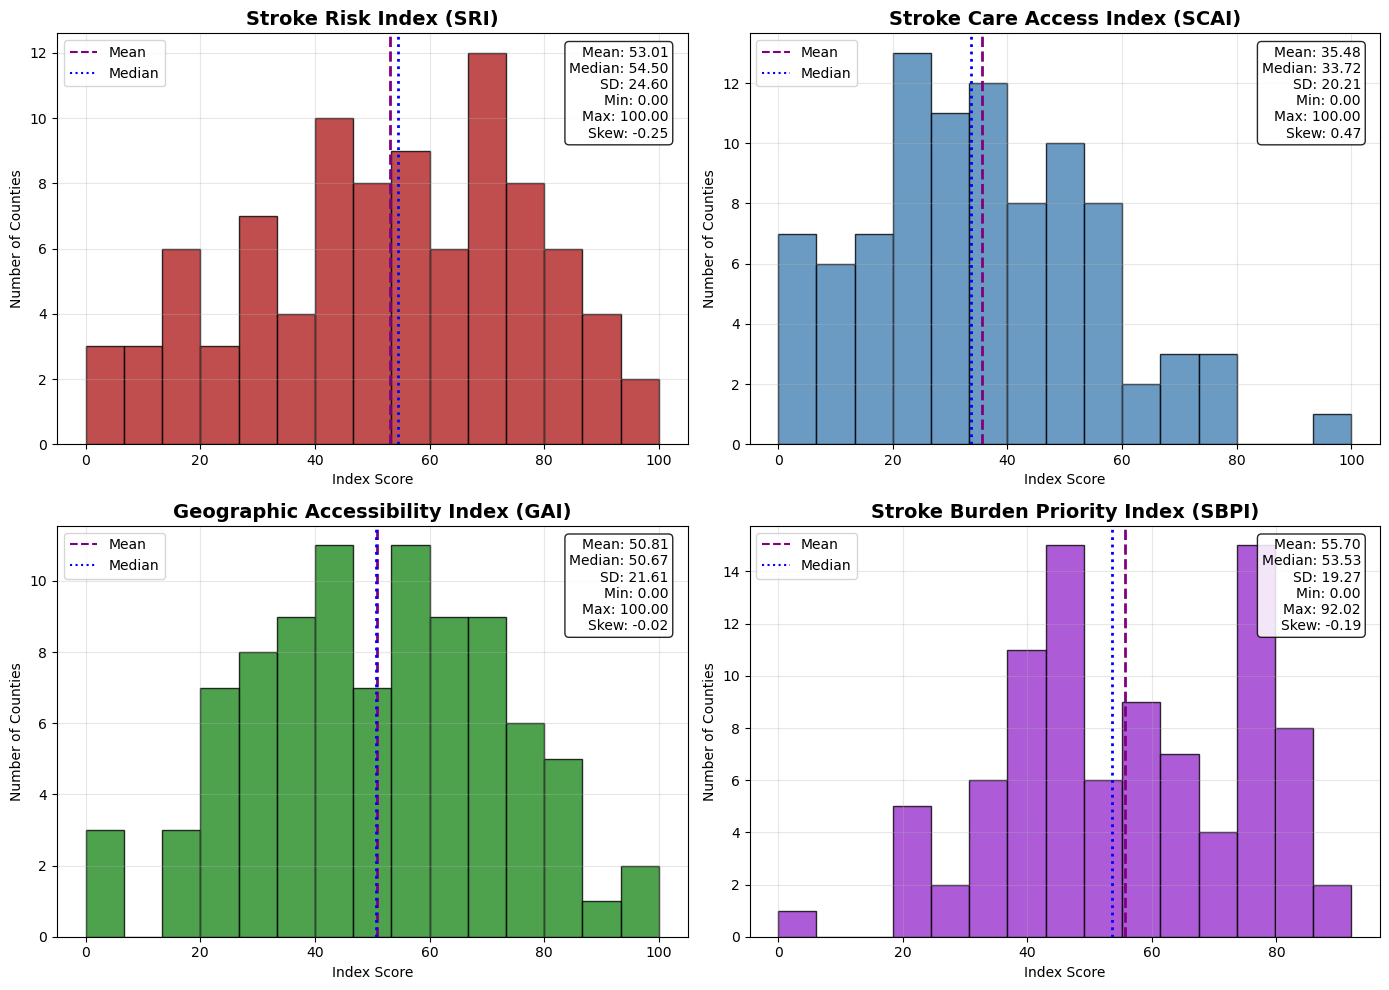

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, index_cols):

    data = df[col]

    mean = data.mean()
    median = data.median()
    std = data.std()
    minimum = data.min()
    maximum = data.max()
    skew = data.skew()

    # Histogram
    ax.hist(data,
            bins=15,
            edgecolor="black",
            color=colors[col],
            alpha=0.8)

    # Mean & Median
    ax.axvline(mean,
               color="purple",
               linestyle="--",
               linewidth=2)

    ax.axvline(median,
               color="blue",
               linestyle=":",
               linewidth=2)

    # Title
    ax.set_title(titles[col], fontsize=14, fontweight="bold")

    ax.set_xlabel("Index Score")
    ax.set_ylabel("Number of Counties")

    ax.grid(alpha=0.3)

    # Statistics box
    stats = (
        f"Mean: {mean:.2f}\n"
        f"Median: {median:.2f}\n"
        f"SD: {std:.2f}\n"
        f"Min: {minimum:.2f}\n"
        f"Max: {maximum:.2f}\n"
        f"Skew: {skew:.2f}"
    )

    ax.text(
        0.97, 0.97,
        stats,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85
        )
    )

    # Mean/Median legend
    ax.plot([], [], color="purple", linestyle="--", label="Mean")
    ax.plot([], [], color="blue", linestyle=":", label="Median")
    ax.legend(loc="upper left")

plt.tight_layout()

plt.savefig(
    "../docs/images/index_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

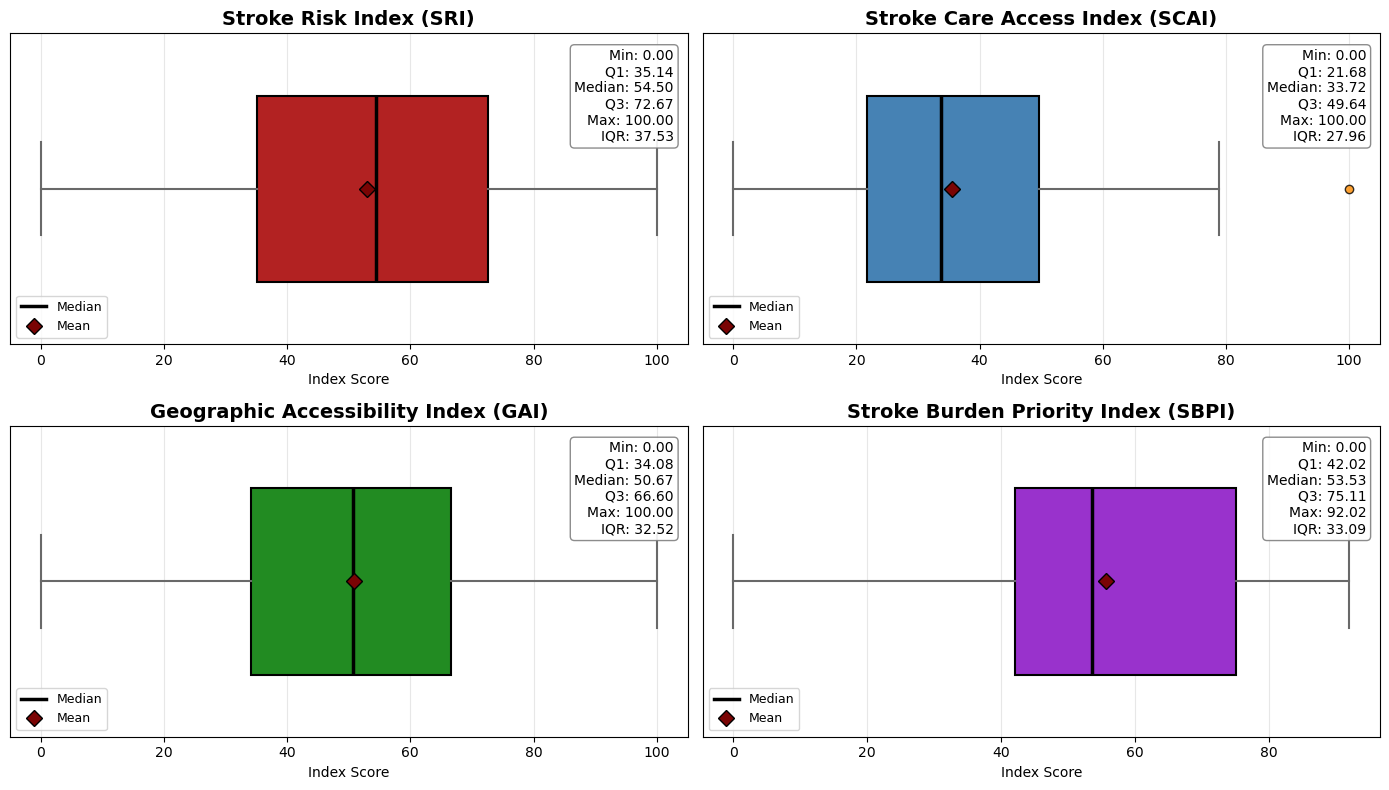

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, index_cols):

    data = df[col]

    # Summary statistics
    mean = data.mean()
    median = data.median()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    minimum = data.min()
    maximum = data.max()

    # Create boxplot
    bp = ax.boxplot(
        data,
        vert=False,
        patch_artist=True,
        widths=0.6,
        showmeans=True,
        meanline=False,
        meanprops=dict(
            marker="D",
            markerfacecolor="#7a0404",
            markeredgecolor="black",
            markersize=8
        ),
        medianprops=dict(
            color="black",
            linewidth=2.5
        ),
        whiskerprops=dict(
            color="dimgray",
            linewidth=1.5
        ),
        capprops=dict(
            color="dimgray",
            linewidth=1.5
        ),
        flierprops=dict(
            marker="o",
            markersize=6,
            markerfacecolor="darkorange",
            markeredgecolor="black",
            alpha=0.8
        )
    )

    # Color the box
    bp["boxes"][0].set(
        facecolor=colors[col],
        edgecolor="black",
        linewidth=1.5
    )

    # Titles and labels
    ax.set_title(titles[col], fontsize=14, fontweight="bold")
    ax.set_xlabel("Index Score")
    ax.set_yticks([])
    ax.grid(axis="x", alpha=0.3)

    # Statistics box
    stats = (
        f"Min: {minimum:.2f}\n"
        f"Q1: {q1:.2f}\n"
        f"Median: {median:.2f}\n"
        f"Q3: {q3:.2f}\n"
        f"Max: {maximum:.2f}\n"
        f"IQR: {iqr:.2f}"
    )

    ax.text(
        0.98,
        0.95,
        stats,
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="right",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        )
    )

    # Legend
    legend_elements = [
        Line2D([0], [0],
               color="black",
               lw=2.5,
               label="Median"),
        Line2D([0], [0],
               marker="D",
               color="#7a0404",
               markeredgecolor="black",
               linestyle="",
               markersize=8,
               label="Mean")
    ]

    ax.legend(handles=legend_elements, loc="lower left", fontsize=9)

plt.tight_layout()

plt.savefig(
    "../docs/images/index_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## County Rankings

The highest- and lowest-scoring counties were identified for each index.

### Top 10:

In [25]:
header_colors = {
    "sri": "#C44E52",
    "scai": "#4C72B0",
    "gai": "#55A868",
    "sbpi": "#8172B2"
}

In [26]:
for col in index_cols:

    print(f"\n{titles[col]} - Top 10 Counties\n")

    top10 = (
        df.nlargest(10, col)[["county", "state", col]]
        .reset_index(drop=True)
    )

    top10.index += 1
    top10.index.name = "Rank"

    # Choose color map based on interpretation of the index
    
    if col in ["sri", "sbpi"]:
        cmap = "RdYlGn_r"   
    else:
        cmap = "RdYlGn"    

    display(
        top10.style
            .format({col: "{:.2f}"})
            .background_gradient(
                subset=[col],
                cmap=cmap,
                vmin=0,
                vmax=100
            )
            .set_caption(f"Top 10 Counties by {titles[col]}")
            .set_properties(**{
                "text-align": "center"
            })
            .set_table_styles([
    {
        "selector": "th",
        "props": [
            ("background-color", header_colors[col]),
            ("color", "white"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "caption",
        "props": [
            ("font-size", "14pt"),
            ("font-weight", "bold")
        ]
    }
])
    )


Stroke Risk Index (SRI) - Top 10 Counties



,county,state,sri
Rank,,,
1,Bronx,NY,100.00
2,Cumberland,NJ,95.12
3,Cattaraugus,NY,91.76
4,Hamilton,NY,91.32
5,Delaware,NY,89.39
6,Franklin,NY,87.57
7,Chautauqua,NY,86.23
8,St. Lawrence,NY,85.87
9,Fulton,NY,85.73



Stroke Care Access Index (SCAI) - Top 10 Counties



,county,state,scai
Rank,,,
1,New York,NY,100.00
2,Warren,NY,78.91
3,Otsego,NY,76.00
4,Albany,NY,73.47
5,Nassau,NY,71.49
6,Westchester,NY,71.28
7,Monroe,NY,68.92
8,Onondaga,NY,65.68
9,Bergen,NJ,63.41



Geographic Accessibility Index (GAI) - Top 10 Counties



,county,state,gai
Rank,,,
1,New York,NY,100.00
2,Kings,NY,96.88
3,Bronx,NY,87.04
4,Broome,NY,86.25
5,Essex,NJ,86.03
6,Queens,NY,84.93
7,Hartford,CT,83.95
8,Passaic,NJ,82.07
9,Onondaga,NY,79.01



Stroke Burden Priority Index (SBPI) - Top 10 Counties



,county,state,sbpi
Rank,,,
1,Hamilton,NY,92.02
2,Delaware,NY,87.99
3,Chenango,NY,83.51
4,Essex,NY,83.35
5,Seneca,NY,82.08
6,Orleans,NY,81.85
7,Fulton,NY,81.52
8,St. Lawrence,NY,81.19
9,Lewis,NY,80.89


### Bottom 10

In [28]:
for col in index_cols:

    print(f"\n{titles[col]} - Bottom 10 Counties\n")

    bottom10 = (
        df.nsmallest(10, col)[["county", "state", col]]
        .reset_index(drop=True)
    )

    bottom10.index += 1
    bottom10.index.name = "Rank"

    # Choose color map based on index direction
    
    if col in ["sri", "sbpi"]:
        cmap = "RdYlGn_r"
    else:
        cmap = "RdYlGn"

    display(
        bottom10.style
            .format({col: "{:.2f}"})
            .background_gradient(
                subset=[col],
                cmap=cmap,
                vmin=0,
                vmax=100
            )
            .set_caption(f"Bottom 10 Counties by {titles[col]}")
            .set_properties(**{
                "text-align": "center"
            })
            .set_table_styles([
                {
                    "selector": "th",
                    "props": [
                        ("background-color", header_colors[col]),
                        ("color", "white"),
                        ("font-weight", "bold"),
                        ("text-align", "center"),
                        ("font-size", "11pt")
                    ]
                },
                {
                    "selector": "td",
                    "props": [
                        ("text-align", "center"),
                        ("padding", "6px")
                    ]
                },
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("font-size", "14pt"),
                        ("font-weight", "bold"),
                        ("padding", "8px")
                    ]
                }
            ])
    )


Stroke Risk Index (SRI) - Bottom 10 Counties



,county,state,sri
Rank,,,
1,New York,NY,0.00
2,Morris,NJ,1.19
3,Somerset,NJ,6.08
4,Tompkins,NY,7.59
5,Hunterdon,NJ,8.35
6,Bergen,NJ,12.60
7,Nassau,NY,15.17
8,Fairfield,CT,16.38
9,Westchester,NY,17.11



Stroke Care Access Index (SCAI) - Bottom 10 Counties



,county,state,scai
Rank,,,
1,Hamilton,NY,0.00
2,Orleans,NY,0.26
3,Seneca,NY,0.87
4,Tioga,NY,3.41
5,Washington,NY,4.04
6,Greene,NY,4.83
7,Herkimer,NY,5.27
8,Schoharie,NY,8.72
9,Cayuga,NY,9.54



Geographic Accessibility Index (GAI) - Bottom 10 Counties



,county,state,gai
Rank,,,
1,Clinton,NY,0.00
2,Franklin,NY,4.95
3,Essex,NY,6.29
4,Delaware,NY,15.50
5,Chautauqua,NY,17.50
6,Hamilton,NY,18.20
7,Steuben,NY,21.19
8,Lewis,NY,23.48
9,Schoharie,NY,24.27



Stroke Burden Priority Index (SBPI) - Bottom 10 Counties



,county,state,sbpi
Rank,,,
1,New York,NY,0.00
2,Nassau,NY,21.66
3,Westchester,NY,21.69
4,Morris,NJ,21.98
5,Bergen,NJ,22.45
6,Somerset,NJ,24.02
7,Albany,NY,27.37
8,Hunterdon,NJ,28.90
9,Monmouth,NJ,30.82


## Relationships Between the Indices

Pearson correlations were calculated to evaluate how the four indices relate to one another.

In [30]:
# Constructing correlation matrix

corr = df[
    ["sri","scai","gai","sbpi"]
].corr()

corr

,sri,scai,gai,sbpi
sri,1.000000,-0.543384,-0.517596,0.925314
scai,-0.543384,1.000000,0.544884,-0.783637
gai,-0.517596,0.544884,1.000000,-0.726108
sbpi,0.925314,-0.783637,-0.726108,1.000000


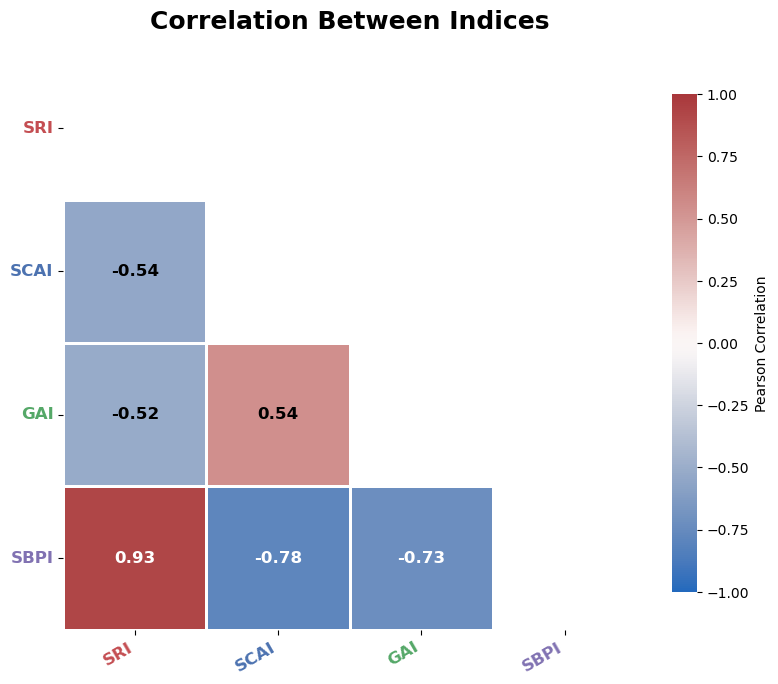

In [31]:
# Mask the UPPER triangle so the LOWER triangle is shown

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 7))

ax = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=2,
    linecolor="white",
    cbar_kws={
        "label": "Pearson Correlation",
        "shrink": 0.8
    },
    annot_kws={
        "size": 12,
        "weight": "bold"
    }
)

# Title
ax.set_title(
    "Correlation Between Indices",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Tick labels
labels = ["SRI", "SCAI", "GAI", "SBPI"]

ax.set_xticklabels(
    labels,
    fontsize=12,
    fontweight="bold",
    rotation=30,
    ha="right"
)

ax.set_yticklabels(
    labels,
    fontsize=12,
    fontweight="bold",
    rotation=0
)

label_colors = {
    "SRI": "#C44E52",
    "SCAI": "#4C72B0",
    "GAI": "#55A868",
    "SBPI": "#8172B2"
}

for tick in ax.get_xticklabels():
    tick.set_color(label_colors[tick.get_text()])

for tick in ax.get_yticklabels():
    tick.set_color(label_colors[tick.get_text()])

# Make annotation colors dynamic

for text in ax.texts:
    try:
        value = float(text.get_text())
        text.set_color("white" if abs(value) > 0.65 else "black")
    except ValueError:
        pass

plt.tight_layout()

plt.savefig(
    "../docs/images/index_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Pairwise Relationships

Scatterplots were generated to visualize relationships among the component indices.

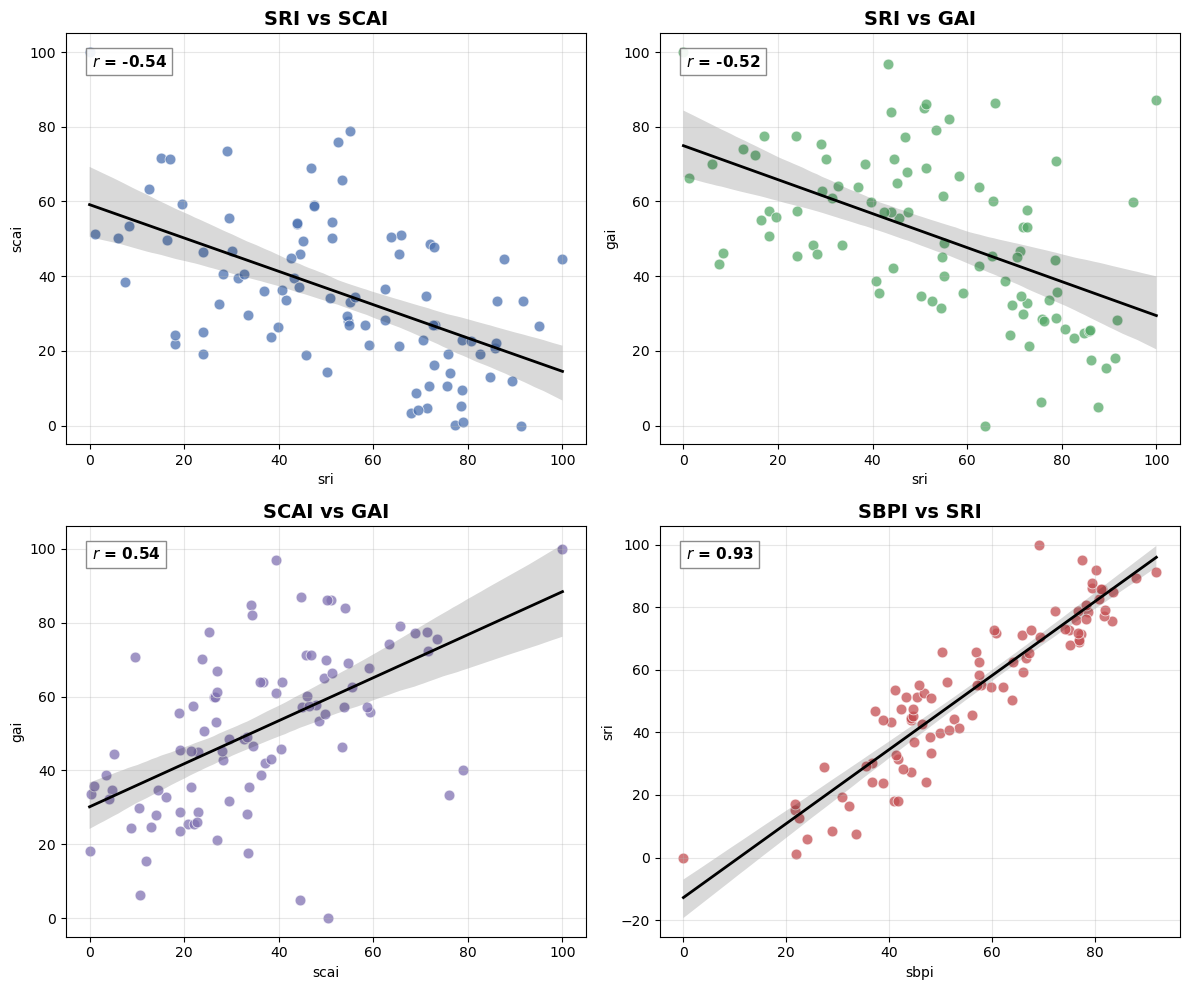

In [33]:
pairs = [
    ("sri", "scai"),
    ("sri", "gai"),
    ("scai", "gai"),
    ("sbpi", "sri")
]

titles = {
    ("sri", "scai"): "SRI vs SCAI",
    ("sri", "gai"): "SRI vs GAI",
    ("scai", "gai"): "SCAI vs GAI",
    ("sbpi", "sri"): "SBPI vs SRI"
}

colors = {
    ("sri", "scai"): "#4C72B0",
    ("sri", "gai"): "#55A868",
    ("scai", "gai"): "#8172B2",
    ("sbpi", "sri"): "#C44E52"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):

    sns.regplot(
        data=df,
        x=x,
        y=y,
        ax=ax,
        scatter_kws={
            "s": 60,
            "alpha": 0.75,
            "edgecolor": "white",
            "linewidths": 0.6,
            "color": colors[(x, y)]
        },
        line_kws={
            "color": "black",
            "linewidth": 2
        }
    )

    # Correlation coefficients
    
    r = df[[x, y]].corr().iloc[0, 1]

    ax.text(
        0.05,
        0.95,
        f"$r$ = {r:.2f}",
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
        bbox=dict(
            facecolor="white",
            alpha=0.9,
            edgecolor="gray"
        )
    )

    ax.set_title(
        titles[(x, y)],
        fontsize=14,
        fontweight="bold"
    )

    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../docs/images/index_relationships.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Comparison by State

Average index scores were compared across New York, New Jersey, and Connecticut.

In [35]:
state_summary = df.groupby("state")[
    ["sri","scai","gai","sbpi"]
].agg(["mean","std"])

state_summary

sri                  scai                   gai             \
            mean        std       mean        std       mean        std   
state                                                                     
CT     35.925612  14.756776  39.329225  13.910687  51.898988  14.950187   
NJ     38.569557  23.982614  41.174671  13.486522  63.666486  12.137348   
NY     60.102439  22.756853  33.054737  22.392013  46.318423  23.188991   

            sbpi             
            mean        std  
state                        
CT     45.784238  10.069573  
NJ     44.199081  14.653719  
NY     60.871116  19.497387

In [36]:
# Creating state color palette

colors = {
    "NY": "#4C72B0",
    "NJ": "#55A868",
    "CT": "#C44E52"
}

In [37]:
# Setting titles

titles = {
    "sri": "Stroke Risk Index (SRI)",
    "scai": "Stroke Care Access Index (SCAI)",
    "gai": "Geographic Accessibility Index (GAI)",
    "sbpi": "Stroke Burden Priority Index (SBPI)"
}

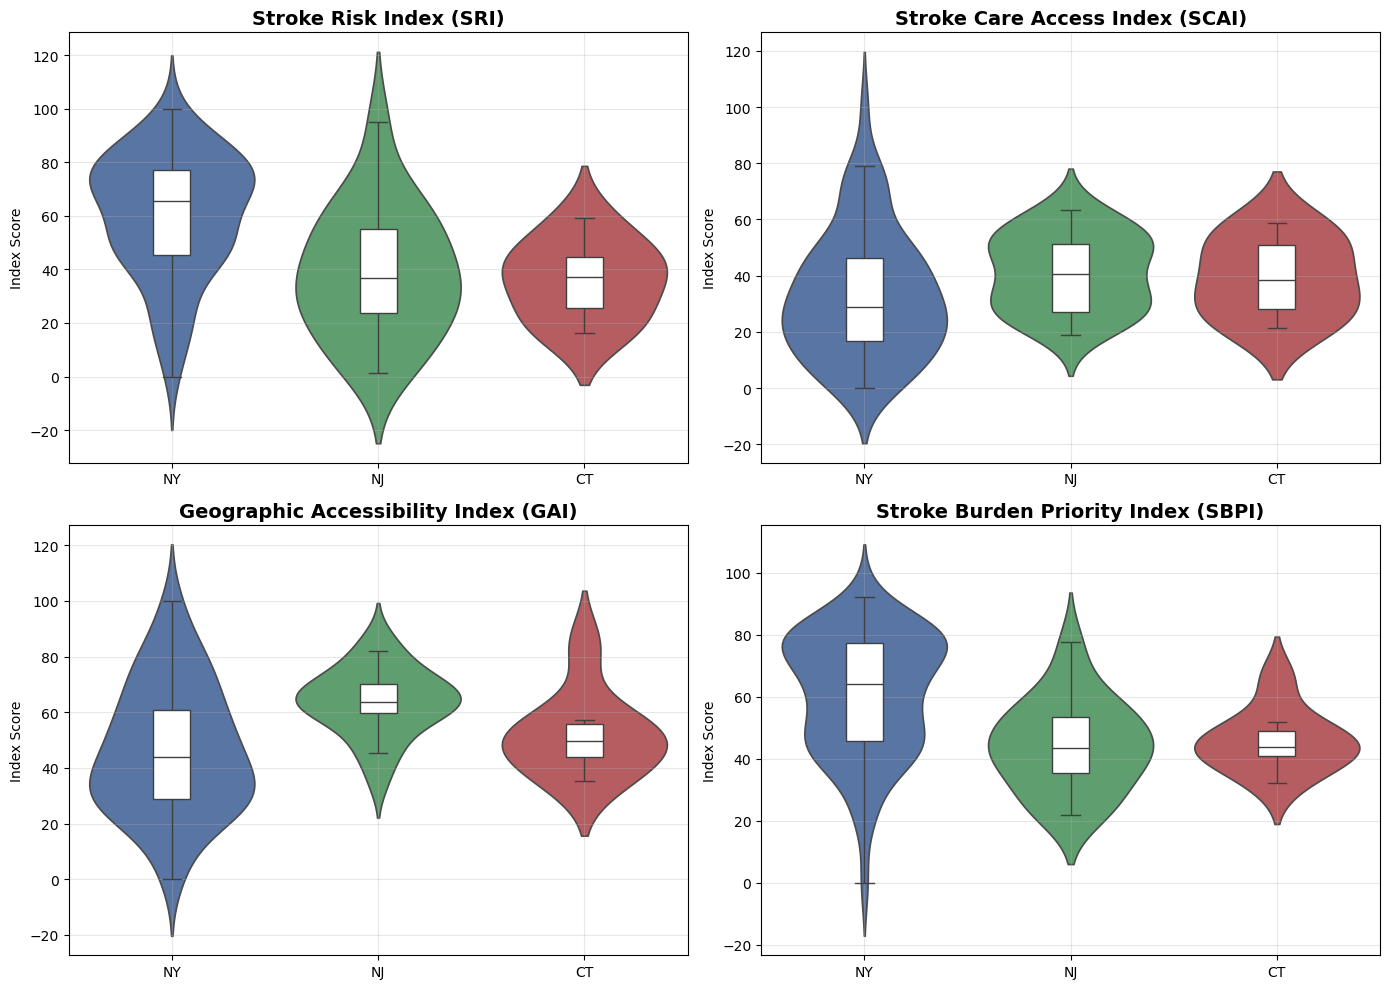

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, index_cols):

    sns.violinplot(
        data=df,
        x="state",
        y=col,
        hue="state",
        palette=colors,
        inner=None,
        legend=False,
        ax=ax
    )

    sns.boxplot(
        data=df,
        x="state",
        y=col,
        width=0.18,
        showfliers=False,
        boxprops=dict(facecolor="white"),
        ax=ax
    )

    ax.set_title(
        titles[col],
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("Index Score")
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../docs/images/state_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Relationship With Stroke Mortality

Correlations between the composite indices and county-level acute stroke mortality were examined to evaluate whether the indices capture meaningful variation in stroke outcomes.

In [40]:
mortality_corr = df[
    [
        "acute_stroke_mortality_per_100k",
        "sri",
        "scai",
        "gai",
        "sbpi"
    ]
].corr()

mortality_corr

,acute_stroke_mortality_per_100k,sri,scai,gai,sbpi
acute_stroke_mortality_per_100k,1.000000,0.432161,-0.228511,-0.347383,0.425647
sri,0.432161,1.000000,-0.543384,-0.517596,0.925314
scai,-0.228511,-0.543384,1.000000,0.544884,-0.783637
gai,-0.347383,-0.517596,0.544884,1.000000,-0.726108
sbpi,0.425647,0.925314,-0.783637,-0.726108,1.000000


In [41]:
# Setting titles 

titles = {
    "sri": "Stroke Risk Index (SRI)",
    "scai": "Stroke Care Access Index (SCAI)",
    "gai": "Geographic Accessibility Index (GAI)",
    "sbpi": "Stroke Burden Priority Index (SBPI)"
}

In [42]:
# Setting colors

colors = {
    "sri": "#C44E52",
    "scai": "#4C72B0",
    "gai": "#55A868",
    "sbpi": "#8172B2"
}

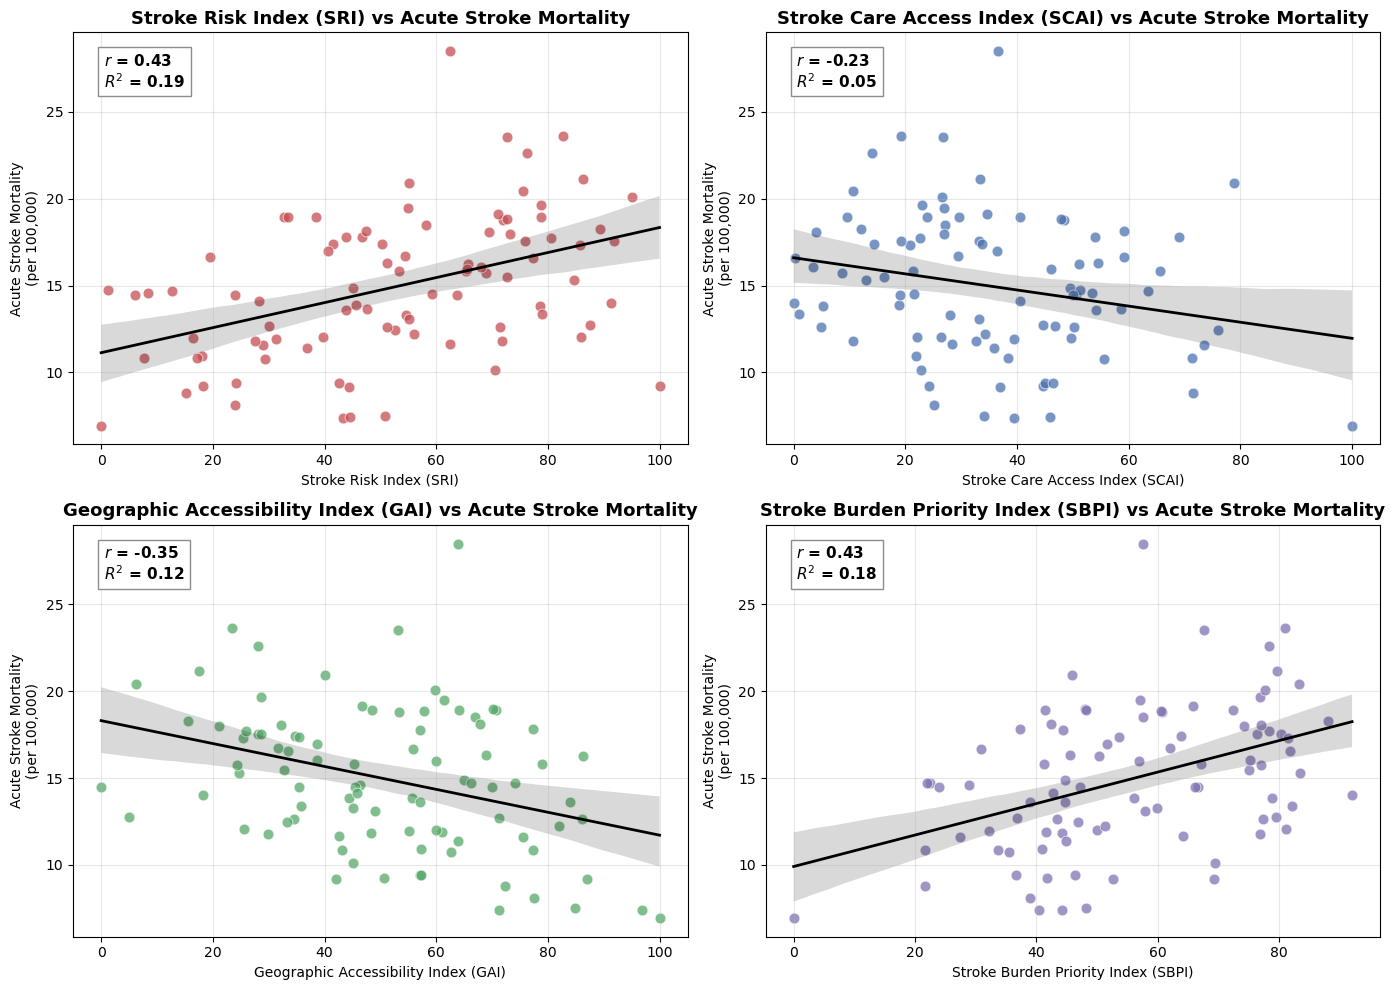

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, index_cols):

    sns.regplot(
        data=df,
        x=col,
        y="acute_stroke_mortality_per_100k",
        ax=ax,
        ci=95,
        scatter_kws={
            "s": 60,
            "alpha": 0.75,
            "color": colors[col],
            "edgecolor": "white",
            "linewidths": 0.6
        },
        line_kws={
            "color": "black",
            "linewidth": 2
        }
    )

    # Pearson correlation
    
    r = df[[col, "acute_stroke_mortality_per_100k"]].corr().iloc[0, 1]
    r2 = r**2

    ax.text(
        0.05,
        0.95,
        f"$r$ = {r:.2f}\n$R^2$ = {r2:.2f}",
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            alpha=0.9
        )
    )

    ax.set_title(
        f"{titles[col]} vs Acute Stroke Mortality",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(titles[col])
    ax.set_ylabel("Acute Stroke Mortality\n(per 100,000)")
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../docs/images/mortality_relationships.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Stroke Burden Priority Counties

The Stroke Burden Priority Index (SBPI) combines stroke risk, healthcare resource availability, and geographic accessibility into a single measure for identifying counties that may benefit from targeted public health interventions.

### Ranked Table

In [46]:
priority = (
    df.sort_values("sbpi", ascending=False)
      [["county", "state", "sbpi", "sbpi_class"]]
      .head(20)
)

priority.index += 1
priority.index.name = "Rank"

display(
    priority.style
    .format({"sbpi": "{:.2f}"})
    .background_gradient(
        subset=["sbpi"],
        cmap="RdYlGn_r",
        vmin=0,
        vmax=100
    )
    .set_caption("Top 20 Counties by Stroke Burden Priority Index")
)

,county,state,sbpi,sbpi_class
Rank,,,,
21,Hamilton,NY,92.02,4
13,Delaware,NY,87.99,4
9,Chenango,NY,83.51,4
16,Essex,NY,83.35,4
50,Seneca,NY,82.08,3
37,Orleans,NY,81.85,4
18,Fulton,NY,81.52,4
45,St. Lawrence,NY,81.19,3
25,Lewis,NY,80.89,4


### Bar Chart

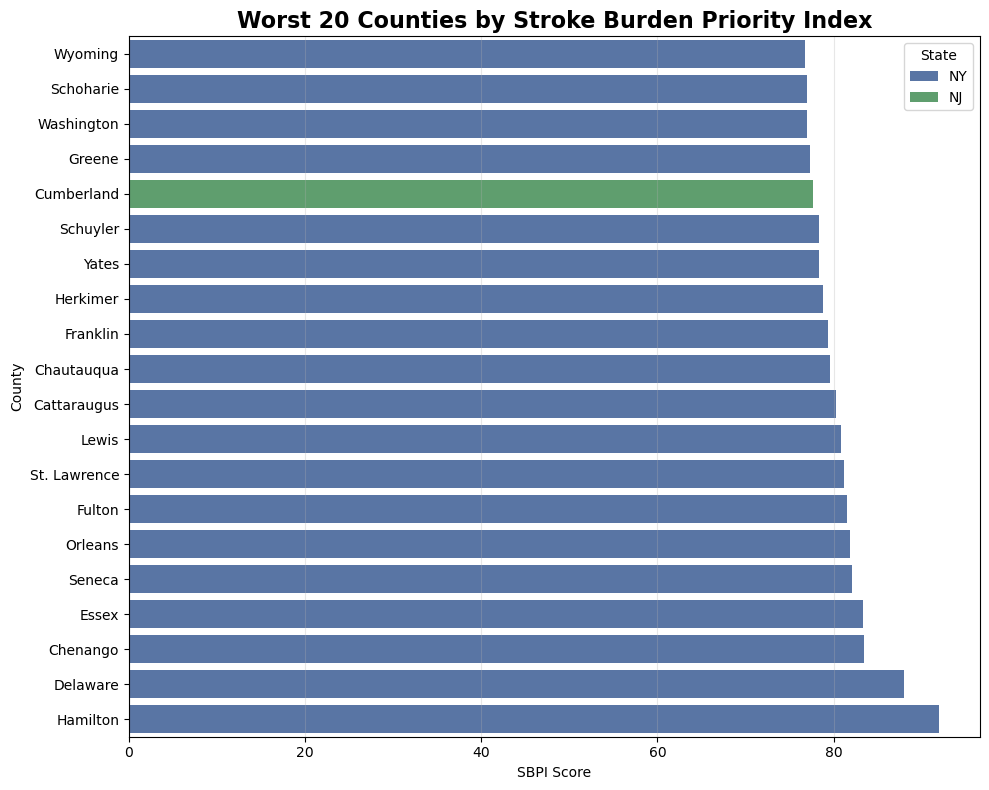

In [48]:
top20 = (
    df.nlargest(20, "sbpi")
      .sort_values("sbpi")
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    x="sbpi",
    y="county",
    hue="state",
    dodge=False,
    palette={
        "NY":"#4C72B0",
        "NJ":"#55A868",
        "CT":"#C44E52"
    }
)

plt.title(
    "Worst 20 Counties by Stroke Burden Priority Index",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("SBPI Score")
plt.ylabel("County")
plt.grid(axis="x", alpha=.3)

plt.legend(title="State")

plt.tight_layout()
plt.show()

### Showing SBPI Classes

In [50]:
class_counts = (
    df["sbpi_class"]
      .value_counts()
      .sort_index()
)

class_counts

sbpi_class
1    55
2    16
3    10
4    10
Name: count, dtype: int64

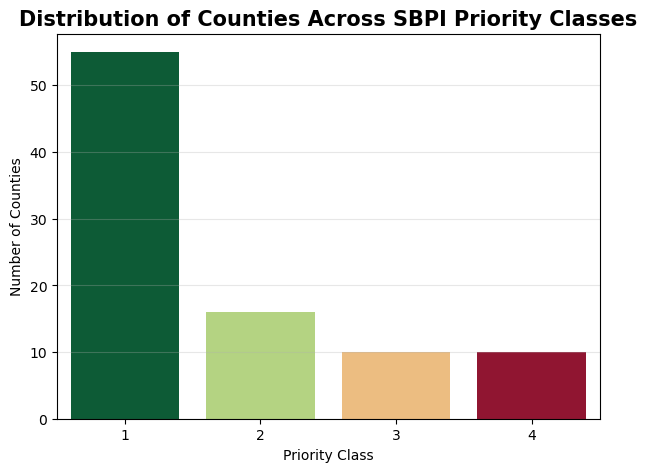

In [51]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="sbpi_class",
    hue="sbpi_class",
    palette="RdYlGn_r",
    legend=False
)

plt.title(
    "Distribution of Counties Across SBPI Priority Classes",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Priority Class")
plt.ylabel("Number of Counties")

plt.grid(axis="y", alpha=.3)


plt.savefig(
    "../docs/images/sbpi_priority_counties.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Summary Statistics by Class

In [53]:
df.groupby("sbpi_class")[
    [
        "sbpi",
        "sri",
        "scai",
        "gai",
        "acute_stroke_mortality_per_100k"
    ]
].mean().round(2)

,sbpi,sri,scai,gai,acute_stroke_mortality_per_100k
sbpi_class,,,,,
1,43.60,39.26,45.09,62.52,14.05
2,66.78,64.07,26.23,36.93,14.67
3,78.13,82.78,20.35,35.78,17.23
4,82.08,81.15,12.54,23.66,18.12


### SBPI State Comparison

<Axes: xlabel='state', ylabel='sbpi'>

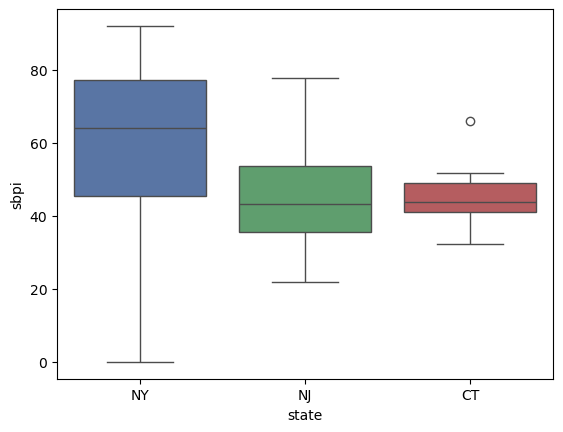

In [55]:
sns.boxplot(
    data=df,
    x="state",
    y="sbpi",
    hue="state",
    palette={
        "NY":"#4C72B0",
        "NJ":"#55A868",
        "CT":"#C44E52"
    },
    legend=False
)

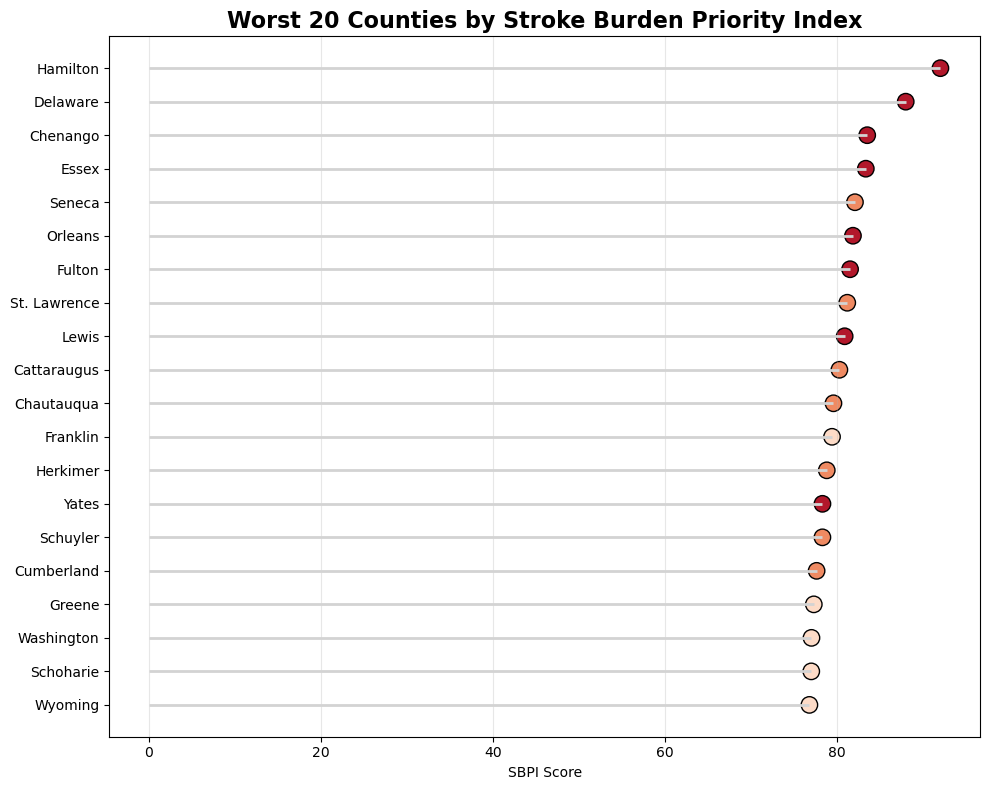

In [56]:
top20 = (
    df.nlargest(20, "sbpi")
      .sort_values("sbpi")
)

plt.figure(figsize=(10,8))

plt.hlines(
    y=top20["county"],
    xmin=0,
    xmax=top20["sbpi"],
    color="lightgray",
    linewidth=2
)

class_colors = {
    4: "#B2182B",
    3: "#EF8A62",
    2: "#FDDBC7",
}

colors = top20["sbpi_class"].map(class_colors)

plt.scatter(
    top20["sbpi"],
    top20["county"],
    s=140,
    c=colors,
    edgecolor="black"
)

plt.xlabel("SBPI Score")
plt.title(
    "Worst 20 Counties by Stroke Burden Priority Index",
    fontsize=16,
    fontweight="bold"
)

plt.grid(axis="x", alpha=.3)

plt.tight_layout()

plt.savefig(
    "../docs/images/sbpi_priority_counties.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()